# py-CytoTRACE tutorial — synthetic stemness gradient

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pycytotrace
print(f'pycytotrace {pycytotrace.__version__}')

pycytotrace 0.1.0


## 2. Build a synthetic stemness gradient

Cells with smaller index have more detectably-expressed genes (= more stem-like).

In [2]:
rng = np.random.RandomState(42)
n_cells, n_genes = 100, 200
counts = rng.poisson(2.0, (n_genes, n_cells)).astype(float)
gold_pt = np.linspace(0, 1, n_cells)
for c in range(n_cells):
    extra = rng.choice(n_genes, size=max(1, n_cells - c), replace=False)
    counts[extra, c] += rng.poisson(5.0, len(extra))
print('counts:', counts.shape)

counts: (200, 100)


## 3. Run cytotrace_run

In [3]:
res = pycytotrace.cytotrace_run(counts)
print('cytotrace shape:', res.cytotrace.shape)
print('first cells (stem-like):', res.cytotrace[:5].round(3))
print('last cells (differentiated):', res.cytotrace[-5:].round(3))

cytotrace shape: (100,)
first cells (stem-like): [0.949 0.97  0.929 0.99  0.96 ]
last cells (differentiated): [0.525 0.566 0.343 0.232 0.121]


## 4. Inspect top-correlated genes

In [4]:
print('Top 10 cytotrace-correlated genes:')
print(res.cyto_genes.head(10).round(3))
print('\nBottom 10 (anti-correlated):')
print(res.cyto_genes.tail(10).round(3))

Top 10 cytotrace-correlated genes:
gene_17     0.317
gene_117    0.309
gene_131    0.283
gene_42     0.277
gene_26     0.272
gene_0      0.265
gene_110    0.263
gene_172    0.255
gene_188    0.242
gene_71     0.241
dtype: float64

Bottom 10 (anti-correlated):
gene_9     -0.136
gene_3     -0.138
gene_114   -0.146
gene_124   -0.147
gene_174   -0.150
gene_144   -0.152
gene_173   -0.155
gene_194   -0.156
gene_14    -0.157
gene_41    -0.236
dtype: float64


## 5. Visualise on a 2-D embedding

Saving 6 x 4 in image to cytotrace_emb.png


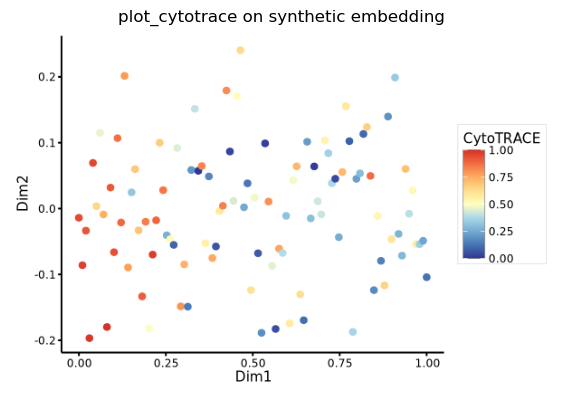

In [5]:
from ggplot2_py import ggsave
embedding = np.column_stack([gold_pt, rng.normal(0, 0.1, n_cells)])
p = pycytotrace.plot_cytotrace(res, embedding=embedding)
ggsave('cytotrace_emb.png', plot=p, width=6, height=4, dpi=100)
from PIL import Image
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(Image.open('cytotrace_emb.png')); ax.axis('off')
ax.set_title('plot_cytotrace on synthetic embedding'); plt.show()

## 6. Bar plot of top genes

Saving 8 x 4 in image to cytotrace_genes.png


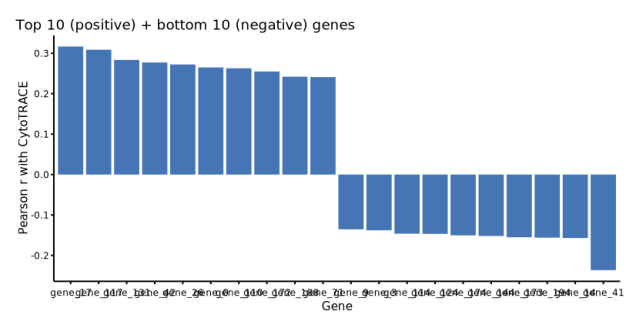

In [6]:
p2 = pycytotrace.plot_cyto_genes(res, n_top=10, n_bottom=10)
ggsave('cytotrace_genes.png', plot=p2, width=8, height=4, dpi=100)
fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(Image.open('cytotrace_genes.png')); ax.axis('off'); plt.show()